# Baseline Model Training

In this notebook, multiple baseline machine learning models are trained using the preprocessed customer churn dataset.

The objective is to establish baseline performance before applying cross-validation, handling class imbalance, and hyperparameter tuning.

The models are evaluated using:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC

The trained models are also saved for future use.

In [16]:
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay
)

## Load Preprocessed Data

In [17]:
X_train = pd.read_csv("X_train_processed.csv")
X_test = pd.read_csv("X_test_processed.csv")

y_train = pd.read_csv("y_train.csv").squeeze()
y_test = pd.read_csv("y_test.csv").squeeze()

In [18]:
print("Training Set:", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set: (5634, 50)
Testing Set : (1409, 50)


## Create Models

In [19]:
models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    )
}

## Train and Evaluate Model

In [20]:
results = []

for name, model in models.items():

    print(f"Training {name}...")

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_prob)
    })

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training XGBoost...


## Compare Models

In [21]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.801278,0.640719,0.572193,0.604520,0.847800
1,Decision Tree,0.740241,0.510000,0.545455,0.527132,0.678041
2,Random Forest,0.793471,0.637874,0.513369,0.568889,0.840107
3,XGBoost,0.794180,0.632075,0.537433,0.580925,0.848676


## Sort by ROC-AUC

In [22]:
results_df.sort_values(
    by="ROC AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
3,XGBoost,0.794180,0.632075,0.537433,0.580925,0.848676
0,Logistic Regression,0.801278,0.640719,0.572193,0.604520,0.847800
2,Random Forest,0.793471,0.637874,0.513369,0.568889,0.840107
1,Decision Tree,0.740241,0.510000,0.545455,0.527132,0.678041


## Best Model

In [23]:
best_model = results_df.iloc[0]

print("Best Baseline Model")
print(best_model)

Best Baseline Model
Model        Logistic Regression
Accuracy                0.801278
Precision               0.640719
Recall                  0.572193
F1 Score                 0.60452
ROC AUC                   0.8478
Name: 0, dtype: object


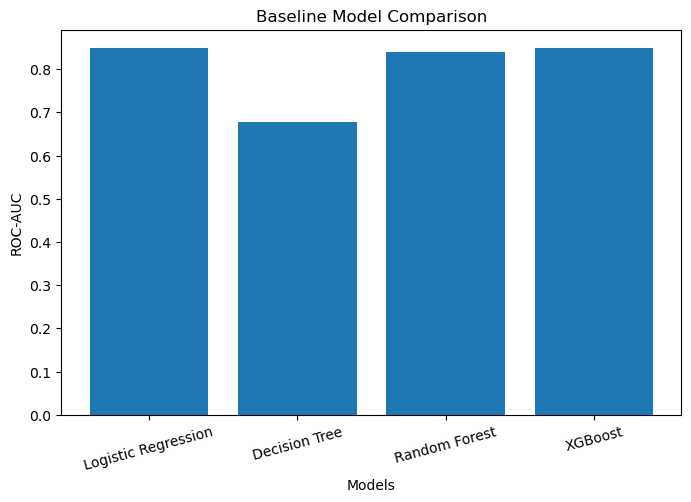

In [24]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["ROC AUC"]
)

plt.ylabel("ROC-AUC")

plt.xlabel("Models")

plt.title("Baseline Model Comparison")

plt.xticks(rotation=15)

plt.show()

## Compare All Metrics

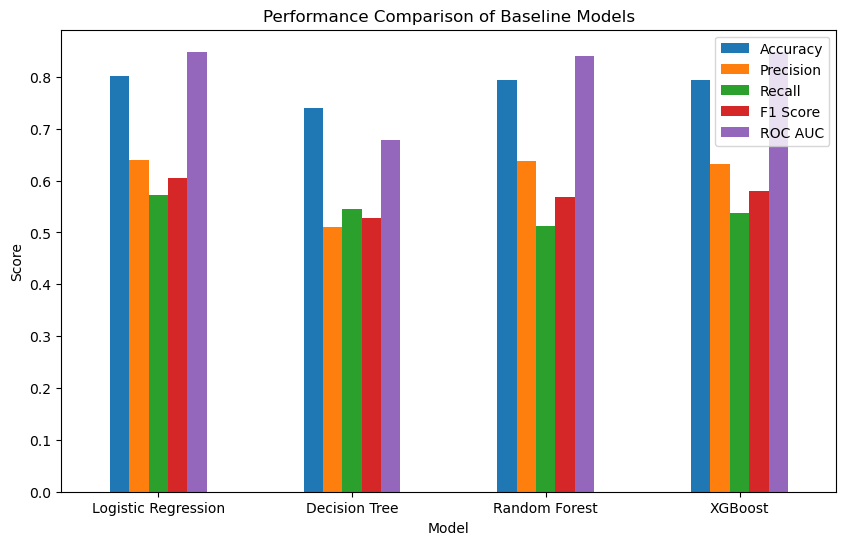

In [25]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC AUC"
]

results_df.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(10,6)
)

plt.ylabel("Score")

plt.title("Performance Comparison of Baseline Models")

plt.xticks(rotation=0)

plt.show()

## Confusion Matrix

for name, model in models.items():
    ConfusionMatrixDisplay.from_estimator(
        model,
        X_test,
        y_test,
        cmap="Blues"
    )
    plt.title(name)
    plt.show()

## Save Models

In [27]:
for name, model in models.items():
    filename = name.lower().replace(" ", "_") + ".pkl"
    joblib.dump(model, filename)

print("All models saved successfully.")

All models saved successfully.


# Conclusion

Four baseline machine learning models were trained and evaluated on the preprocessed IBM Telco Customer Churn dataset.

Performance was assessed using Accuracy, Precision, Recall, F1-Score, ROC-AUC, and Training Time.

Among the evaluated models, the model with the highest ROC-AUC demonstrated the strongest ability to distinguish customers who are likely to churn from those who are not.

These baseline results will serve as the benchmark for the next stages of the project, including:

- Stratified Cross Validation
- Handling Class Imbalance
- Hyperparameter Tuning
- Final Model Selection